In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# # dx = 1 km; Np = 1M; Nt = 5 min
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
# res='1km';t_res='5min';Np_str='1e6'

# dx = 1km; Np = 50M
#Importing Model Data
check=False
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'


# dx = 250 m
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

In [24]:
#READING BACK IN
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
out_file = dir2 + 'Variable_Calculation/' + f'Eulerian_Binary_Array_{res}_{t_res}.h5'

ds = xr.open_dataset(
    out_file,
    engine='h5netcdf',  # Use the correct engine based on the file type
    phony_dims='sort',
    chunks = {'phony_dim_0': 100,
              'phony_dim_1': 34,
              'phony_dim_2': 100,
              'phony_dim_3': 64#128
             }
)

# Rename the dimensions
ds = ds.rename({
    'phony_dim_0': 't',   # Rename phony_dim_0 to 't'
    'phony_dim_1': 'z',   # Rename phony_dim_1 to 'z'
    'phony_dim_2': 'y',   # Rename phony_dim_2 to 'y'
    'phony_dim_3': 'x'    # Rename phony_dim_3 to 'x'
})

ds

# A=ds['A_c'].isel(t=slice(300,500))
# A

<xarray.Dataset>
Dimensions:  (t: 661, z: 34, y: 200, x: 512)
Dimensions without coordinates: t, z, y, x
Data variables:
    A_c      (t, z, y, x) bool dask.array<chunksize=(100, 34, 100, 64), meta=np.ndarray>
    A_g      (t, z, y, x) bool dask.array<chunksize=(100, 34, 100, 64), meta=np.ndarray>

In [ ]:
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
out_file = dir2 + 'Variable_Calculation/' + f'Eulerian_Binary_Array_{res}_{t_res}.h5'

with h5py.File(out_file, 'r') as f:
    A_c=f['A_c'][300:500]

In [ ]:
################################################
# W

In [ ]:
# #FULL DOMAIN VERTICAL PROFILE
# # w = data['winterp'].chunk({'time': 50})
# w = data['winterp'].isel(time=slice(300,500)).chunk({'time': 50})
# mean_w = w.mean(dim=('yh', 'xh'))
# from dask.diagnostics import ProgressBar
# with ProgressBar():
#     result = mean_w.compute()


# result_out=result.values
# z_result_out = np.mean(result_out, axis=0)

In [2]:
out=data['winterp'].isel(time=slice(300,500)).data
result_out=np.mean(out,axis=(2,3))
z_result_out = np.mean(result_out, axis=0)

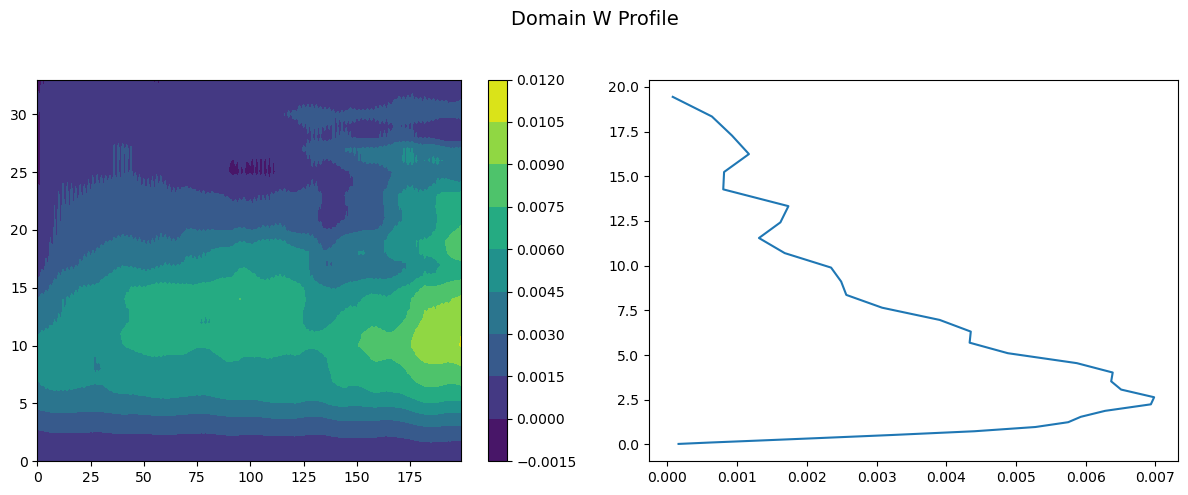

In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# First subplot: Contour plot
cf = axs[0].contourf(result_out.T)
fig.colorbar(cf, ax=axs[0])

# Second subplot: Vertical profile
axs[1].plot(z_result_out, data['zh'])


# Suptitle
fig.suptitle("Domain W Profile", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to accommodate suptitle
plt.show()


In [ ]:
################################
# A TIMES W

In [29]:
masked=out*A_c

In [30]:
masked_mean=np.mean(masked,axis=(2,3))
z_masked_mean=np.mean(masked_mean,axis=(0))

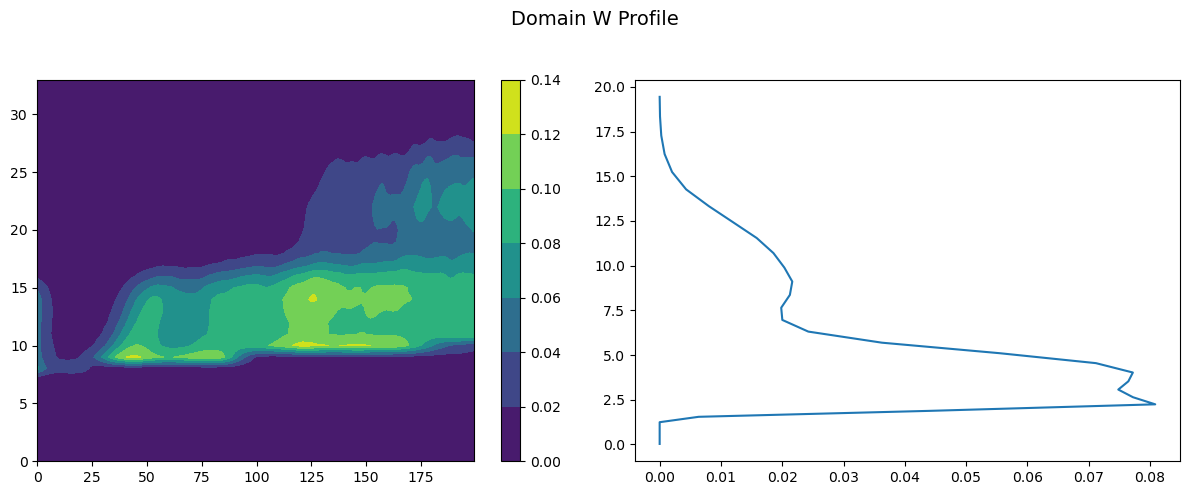

In [35]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# First subplot: Contour plot
cf = axs[0].contourf(masked_mean.T)
fig.colorbar(cf, ax=axs[0])

# Second subplot: Vertical profile
axs[1].plot(z_masked_mean, data['zh'])


# Suptitle
fig.suptitle("Domain W Profile", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to accommodate suptitle
plt.show()


In [ ]:
################################
# Cloudy Updraft W (nanmean)

In [38]:
masked=out.copy()
masked[A_c==False]=np.nan
masked_mean=np.nanmean(masked,axis=(2,3))
z_masked_mean=np.nanmean(masked_mean,axis=(0))

/tmp/ipykernel_1532189/1794690760.py:3: RuntimeWarning: Mean of empty slice
  masked_mean=np.nanmean(masked,axis=(2,3))
/tmp/ipykernel_1532189/1794690760.py:4: RuntimeWarning: Mean of empty slice
  z_masked_mean=np.nanmean(masked_mean,axis=(0))


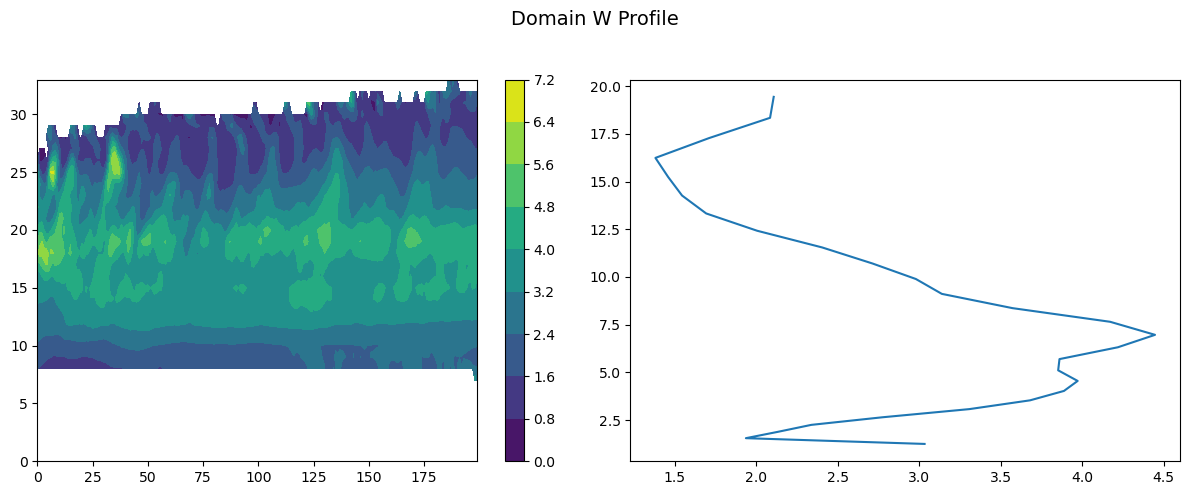

In [39]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# First subplot: Contour plot
cf = axs[0].contourf(masked_mean.T)
fig.colorbar(cf, ax=axs[0])

# Second subplot: Vertical profile
axs[1].plot(z_masked_mean, data['zh'])


# Suptitle
fig.suptitle("Domain W Profile", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to accommodate suptitle
plt.show()


In [44]:
#CHECKING SOME VARIABLES AT TOP OF THE DOMAIN
w=data['winterp'].isel(time=slice(300,500),yh=100,zh=slice(20,34))

In [46]:
w_t=w.isel(time=0)

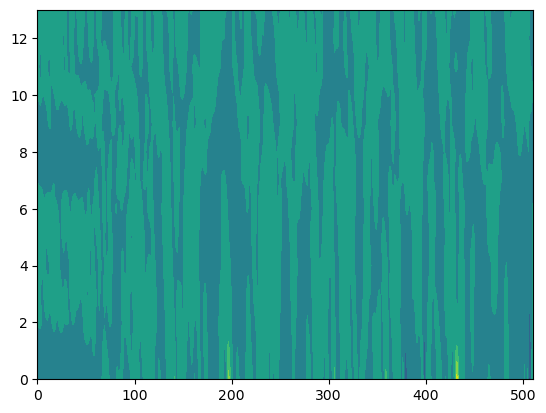

In [48]:
plt.contourf(w_t)